# **TikTok Project**

In this project, the goal was to build a machine learning model that can determine whether a TikTok video presents a claim or an opinion. A successful prediction model will help reduce the backlog of user reports, allowing for more efficient prioritization and management.


# **Classifying videos using machine learning**

In this project, machine learning techniques are used to predict a binary outcome variable for TikTok videos.

The primary objective of this model is to improve system efficiency by automating the initial stages of the claims process, ultimately reducing response times. The goal of the project is to develop a model that can determine whether a TikTok video presents a "claim" or an "opinion." The project consists of three parts:

Part 1: Ethical Considerations
This section explores the ethical implications of the project and considers whether the model’s objective should be adjusted based on those insights.

Part 2: Feature Engineering
Here, data preparation techniques are applied, including feature selection, extraction, and transformation, to prepare the dataset for modeling.

Part 3: Modeling
The final step involves building the models, evaluating their performance, and providing recommendations for next steps.

Upon completion, an Executive Summary will be provided, addressing key questions related to the project, such as those outlined in the PACE Strategy Document. This will ensure a comprehensive understanding of the process and results.

# **PACE stages**


Throughout these project notebooks, references are made to the problem-solving framework PACE. The components of the notebook are labeled according to the respective PACE stages: Plan, Analyze, Construct, and Execute.

## **PACE: Plan**

1 -**TikTok** allows users to report videos they believe violate the platform's terms of service. Given the vast number of videos created and viewed daily, the volume of reports is too large for human moderators to review individually.

Analysis shows that content violating the terms of service is more likely to present a claim rather than an opinion. Therefore, distinguishing between claims and opinions is crucial.

To address this, TikTok aims to develop a machine learning model to classify videos as either claims or opinions. Videos categorized as opinions will be deprioritized for human review, while those identified as claims will undergo further processing. For instance, reported claim-based videos could be ranked by the number of reports they receive, ensuring the most frequently flagged content is prioritized for review.

Implementing this machine learning model would significantly enhance the efficiency of moderation, helping human reviewers focus on videos most likely to violate TikTok's terms of service.

2 -  The data dictionary includes a column named claim_status, which is a binary variable indicating whether a video is classified as a claim or an opinion. This will serve as the target variable, meaning the model's objective is to predict whether each video falls into the category of a claim or an opinion. Since the model is predicting a binary outcome, this is a classification task.

3 - To choose the most suitable evaluation metric, it's important to consider potential errors the model could make. There are two types of incorrect predictions:  

- **False positives**: The model incorrectly classifies an opinion as a claim.  
- **False negatives**: The model incorrectly classifies a claim as an opinion.
  
4 - In this scenario, it is preferable for the model to produce false positives rather than false negatives. Accurately identifying videos that violate the terms of service is crucial, even if it means some opinion videos are mistakenly classified as claims.

The impact of misclassification differs:

If an opinion is misclassified as a claim, the video simply goes to human review.
If a claim is misclassified as an opinion, the video may go unnoticed, allowing a potential terms-of-service violation to remain on the platform. Since such violations are associated with "banned" authors, as noted in the data dictionary, failing to identify them could have serious consequences.
Given that minimizing false negatives is the priority, **recall** will be used as the model’s evaluation metric.

**Modeling workflow and model selection process**

Previous work with this data has revealed that there are ~20,000 videos in the sample. This is sufficient to conduct a rigorous model validation workflow, broken into the following steps:

1. Split the data into train/validation/test sets (60/20/20)
2. Fit models and tune hyperparameters on the training set
3. Perform final model selection on the validation set
4. Assess the champion model's performance on the test set

![](https://raw.githubusercontent.com/adacert/tiktok/main/optimal_model_flow_numbered.svg)


### **1. Imports and data loading**

In [55]:
# Import packages for data manipulation
import numpy as np
import pandas as pd

# Import packages for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Import packages for data preprocessing
from sklearn.feature_extraction.text import CountVectorizer

# Import packages for data modeling
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, accuracy_score, recall_score, \
    precision_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from xgboost import plot_importance

Now time to load the data from the provided csv file into a dataframe.

In [56]:
# Load dataset into dataframe
data = pd.read_csv("tiktok_dataset.csv")

## **PACE: Analyze**


### **2: Examine data, summary info, and descriptive stats**

Inspect the first five rows of the dataframe.

In [57]:
# Display first few rows
data.head(10)

,#,claim_status,video_id,video_duration_sec,video_transcription_text,verified_status,author_ban_status,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count
0,1,claim,7017666017,59,someone shared with me that drone deliveries a...,not verified,under review,343296.0,19425.0,241.0,1.0,0.0
1,2,claim,4014381136,32,someone shared with me that there are more mic...,not verified,active,140877.0,77355.0,19034.0,1161.0,684.0
2,3,claim,9859838091,31,someone shared with me that american industria...,not verified,active,902185.0,97690.0,2858.0,833.0,329.0
3,4,claim,1866847991,25,someone shared with me that the metro of st. p...,not verified,active,437506.0,239954.0,34812.0,1234.0,584.0
4,5,claim,7105231098,19,someone shared with me that the number of busi...,not verified,active,56167.0,34987.0,4110.0,547.0,152.0
5,6,claim,8972200955,35,someone shared with me that gross domestic pro...,not verified,under review,336647.0,175546.0,62303.0,4293.0,1857.0
6,7,claim,4958886992,16,someone shared with me that elvis presley has ...,not verified,active,750345.0,486192.0,193911.0,8616.0,5446.0
7,8,claim,2270982263,41,someone shared with me that the best selling s...,not verified,active,547532.0,1072.0,50.0,22.0,11.0
8,9,claim,5235769692,50,someone shared with me that about half of the ...,not verified,active,24819.0,10160.0,1050.0,53.0,27.0
9,10,claim,4660861094,45,someone shared with me that it would take a 50...,verified,active,931587.0,171051.0,67739.0,4104.0,2540.0


Get the number of rows and columns in the dataset.

In [58]:
# Get number of rows and columns
data.shape

(19382, 12)

Get the data types of the columns.

In [59]:
# Get data types of columns
data.dtypes

#                             int64
claim_status                 object
video_id                      int64
video_duration_sec            int64
video_transcription_text     object
verified_status              object
author_ban_status            object
video_view_count            float64
video_like_count            float64
video_share_count           float64
video_download_count        float64
video_comment_count         float64
dtype: object

Get basic information about the dataset.

In [60]:
# Get basic information
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19382 entries, 0 to 19381
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   #                         19382 non-null  int64  
 1   claim_status              19084 non-null  object 
 2   video_id                  19382 non-null  int64  
 3   video_duration_sec        19382 non-null  int64  
 4   video_transcription_text  19084 non-null  object 
 5   verified_status           19382 non-null  object 
 6   author_ban_status         19382 non-null  object 
 7   video_view_count          19084 non-null  float64
 8   video_like_count          19084 non-null  float64
 9   video_share_count         19084 non-null  float64
 10  video_download_count      19084 non-null  float64
 11  video_comment_count       19084 non-null  float64
dtypes: float64(5), int64(3), object(4)
memory usage: 1.8+ MB


Generate basic descriptive statistics about the dataset.

In [61]:
# Generate basic descriptive stats
data.describe()


,#,video_id,video_duration_sec,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count
count,19382.000000,1.938200e+04,19382.000000,19084.000000,19084.000000,19084.000000,19084.000000,19084.000000
mean,9691.500000,5.627454e+09,32.421732,254708.558688,84304.636030,16735.248323,1049.429627,349.312146
std,5595.245794,2.536440e+09,16.229967,322893.280814,133420.546814,32036.174350,2004.299894,799.638865
min,1.000000,1.234959e+09,5.000000,20.000000,0.000000,0.000000,0.000000,0.000000
25%,4846.250000,3.430417e+09,18.000000,4942.500000,810.750000,115.000000,7.000000,1.000000
50%,9691.500000,5.618664e+09,32.000000,9954.500000,3403.500000,717.000000,46.000000,9.000000
75%,14536.750000,7.843960e+09,47.000000,504327.000000,125020.000000,18222.000000,1156.250000,292.000000
max,19382.000000,9.999873e+09,60.000000,999817.000000,657830.000000,256130.000000,14994.000000,9599.000000


Check for and handle missing values.

In [62]:
# Check for missing values
data.isna().sum()

#                             0
claim_status                298
video_id                      0
video_duration_sec            0
video_transcription_text    298
verified_status               0
author_ban_status             0
video_view_count            298
video_like_count            298
video_share_count           298
video_download_count        298
video_comment_count         298
dtype: int64

In [63]:
# Drop rows with missing values
data = data.dropna(axis = 0)
#data.isna().sum() chech for null

In [64]:

# Display first few rows after handling missing values
data.head()

,#,claim_status,video_id,video_duration_sec,video_transcription_text,verified_status,author_ban_status,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count
0,1,claim,7017666017,59,someone shared with me that drone deliveries a...,not verified,under review,343296.0,19425.0,241.0,1.0,0.0
1,2,claim,4014381136,32,someone shared with me that there are more mic...,not verified,active,140877.0,77355.0,19034.0,1161.0,684.0
2,3,claim,9859838091,31,someone shared with me that american industria...,not verified,active,902185.0,97690.0,2858.0,833.0,329.0
3,4,claim,1866847991,25,someone shared with me that the metro of st. p...,not verified,active,437506.0,239954.0,34812.0,1234.0,584.0
4,5,claim,7105231098,19,someone shared with me that the number of busi...,not verified,active,56167.0,34987.0,4110.0,547.0,152.0


Check for and handle duplicates.

In [65]:
# Check for duplicates
data.duplicated().sum()


np.int64(0)

It is important to check for outliers, although tree-based models are inherently robust to them. Therefore, there is no need to remove values based on their position within the distribution.


Check class balance.

In [66]:
# Check class balance
data['claim_status'].value_counts(normalize= True)

claim_status
claim      0.503458
opinion    0.496542
Name: proportion, dtype: float64

## **PACE: Construct**


### **3: Feature engineering**

Calculate the length of each `video_transcription_text` and create a new column in the dataframe to store these values. This column can then be considered as a potential feature for the model.

In [67]:
# Extract the length of each `video_transcription_text` and add this as a column to the dataframe
data = data.copy()
data['text_length'] = data['video_transcription_text'].str.len()

data.head()

,#,claim_status,video_id,video_duration_sec,video_transcription_text,verified_status,author_ban_status,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count,text_length
0,1,claim,7017666017,59,someone shared with me that drone deliveries a...,not verified,under review,343296.0,19425.0,241.0,1.0,0.0,97
1,2,claim,4014381136,32,someone shared with me that there are more mic...,not verified,active,140877.0,77355.0,19034.0,1161.0,684.0,107
2,3,claim,9859838091,31,someone shared with me that american industria...,not verified,active,902185.0,97690.0,2858.0,833.0,329.0,137
3,4,claim,1866847991,25,someone shared with me that the metro of st. p...,not verified,active,437506.0,239954.0,34812.0,1234.0,584.0,131
4,5,claim,7105231098,19,someone shared with me that the number of busi...,not verified,active,56167.0,34987.0,4110.0,547.0,152.0,128


Calculate the average text_length for claims and opinions.

In [68]:
# Calculate the average text_length for claims and opinions
data[['claim_status','text_length']].groupby(by='claim_status').mean()


,text_length
claim_status,
claim,95.376978
opinion,82.722562


Visualize the distribution of `text_length` for claims and opinions.

<Axes: xlabel='text_length', ylabel='Count'>

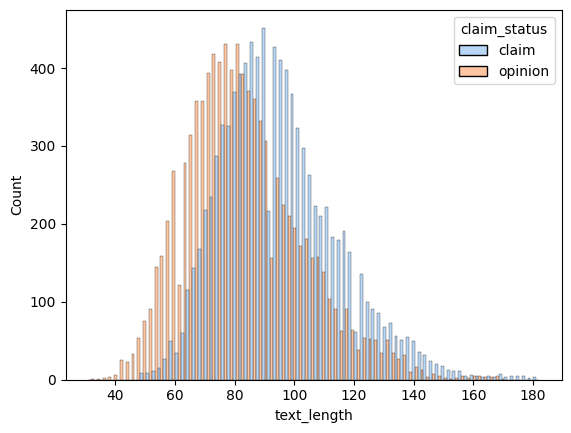

In [69]:
# Visualize the distribution of `text_length` for claims and opinions
# Create two histograms in one plot
sns.histplot(data = data,
             stat = 'count',
             multiple = 'dodge',
             x = 'text_length',
             kde = False,
             palette = 'pastel',
             hue = 'claim_status',
             element = 'bars',
             legend = True)

#### **Feature selection and transformation**

Encode target and catgorical variables.

In [70]:
# Create a copy of the X data
data_copy = data.copy()
# Drop unnecessary columns
data_copy = data_copy.drop(['#', 'video_id', 'video_transcription_text'], axis = 1)

# Encode target variable
data_copy['claim_status'] = data_copy['claim_status'].replace({'opinion': 0, 'claim' : 1})

# Dummy encode remaining categorical values
data_copy = pd.get_dummies( data = data_copy, columns = ['verified_status', 'author_ban_status'],
                           drop_first = True)

data_copy.head()

,claim_status,video_duration_sec,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count,text_length,verified_status_verified,author_ban_status_banned,author_ban_status_under review
0,1,59,343296.0,19425.0,241.0,1.0,0.0,97,False,False,True
1,1,32,140877.0,77355.0,19034.0,1161.0,684.0,107,False,False,False
2,1,31,902185.0,97690.0,2858.0,833.0,329.0,137,False,False,False
3,1,25,437506.0,239954.0,34812.0,1234.0,584.0,131,False,False,False
4,1,19,56167.0,34987.0,4110.0,547.0,152.0,128,False,False,False


In [71]:

# Create a copy of the X data
data_copy = data.copy()
# Drop unnecessary columns
data_copy = data_copy.drop(['#', 'video_id', 'video_transcription_text'], axis = 1)

# Encode target variable
data_copy['claim_status'] = data_copy['claim_status'].replace({'opinion': 0, 'claim' : 1})

# Dummy encode remaining categorical values
data_copy = pd.get_dummies( data = data_copy, columns = ['verified_status', 'author_ban_status'],
                           drop_first = True)

data_copy.head()

,claim_status,video_duration_sec,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count,text_length,verified_status_verified,author_ban_status_banned,author_ban_status_under review
0,1,59,343296.0,19425.0,241.0,1.0,0.0,97,False,False,True
1,1,32,140877.0,77355.0,19034.0,1161.0,684.0,107,False,False,False
2,1,31,902185.0,97690.0,2858.0,833.0,329.0,137,False,False,False
3,1,25,437506.0,239954.0,34812.0,1234.0,584.0,131,False,False,False
4,1,19,56167.0,34987.0,4110.0,547.0,152.0,128,False,False,False


### **Task 4: Split the data**

Assign target variable.

In [72]:
# Isolate target variable
y = data_copy['claim_status']


Isolate the features.

In [73]:
# Isolate features
X = data_copy.drop(['claim_status'], axis =  1)
# Display first few rows of features dataframe
X.head()


,video_duration_sec,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count,text_length,verified_status_verified,author_ban_status_banned,author_ban_status_under review
0,59,343296.0,19425.0,241.0,1.0,0.0,97,False,False,True
1,32,140877.0,77355.0,19034.0,1161.0,684.0,107,False,False,False
2,31,902185.0,97690.0,2858.0,833.0,329.0,137,False,False,False
3,25,437506.0,239954.0,34812.0,1234.0,584.0,131,False,False,False
4,19,56167.0,34987.0,4110.0,547.0,152.0,128,False,False,False


#### **Task 5: Create train/validate/test sets**

Split data into training and testing sets, 80/20.

In [74]:
# Split the data into training and testing sets
X_tr, X_test, y_tr, y_test = train_test_split(X, y, test_size= 0.2, random_state= 0)

Split the training set into training and validation sets, 75/25, to result in a final ratio of 60/20/20 for train/validate/test sets.

In [75]:
# Split the training data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X_tr, y_tr, test_size= 0.25, random_state= 0)

Confirm that the dimensions of the training, validation, and testing sets are in alignment.

In [76]:
# Get shape of each training, validation, and testing set
X_train.shape, X_val.shape, X_test.shape, y_train.shape, y_val.shape, y_test.shape

((11450, 10), (3817, 10), (3817, 10), (11450,), (3817,), (3817,))

### **6. Build models**


### **Build a random forest model**

Fit a random forest model to the training set. Use cross-validation to tune the hyperparameters and select the model that performs best on recall.

In [77]:
# Instantiate the random forest classifier
rf = RandomForestClassifier(random_state= 0)
# Create a dictionary of hyperparameters to tune
cv_params = {'max_depth': [5, 7, None],
             'max_features': [0.3, 0.6],
             'max_samples' : [0.7],
             'min_samples_leaf': [1,2],
             'min_samples_split': [2,3],
             'n_estimators': [50, 100, 200] 
             }

# Define a list of scoring metrics to capture
scoring = {'accuracy': 'accuracy',
            'precision':'precision',
            'recall':'recall',
            'f1':'f1'}

# Instantiate the GridSearchCV object
rf_cv = GridSearchCV(rf, cv_params, cv = 5, scoring = scoring, refit = 'recall')


In [78]:
### Fit the model to the data 
rf_cv.fit(X_train, y_train)


GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=0),
             param_grid={'max_depth': [5, 7, None], 'max_features': [0.3, 0.6],
                         'max_samples': [0.7], 'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 3],
                         'n_estimators': [50, 100, 200]},
             refit='recall',
             scoring={'accuracy': 'accuracy', 'f1': 'f1',
                      'precision': 'precision', 'recall': 'recall'})

In [79]:
# Examine best recall score
rf_cv.best_score_

np.float64(0.9908534395531852)

In [80]:
# Examine best parameters
rf_cv.best_params_


{'max_depth': 5,
 'max_features': 0.6,
 'max_samples': 0.7,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'n_estimators': 50}

Verify the precision score to ensure that the model isn't classifying all instances as claims. To do this, access the `cv_results_` attribute of the fitted `GridSearchCV` object, which provides a numpy array that can be converted to a pandas DataFrame. Once converted, check the `mean_test_precision` column at the index corresponding to the best model, which can be identified using the `best_index_` attribute of the fitted `GridSearchCV` object.

In [81]:
# Access the GridSearch results and convert it to a pandas df
rf_results_df = pd.DataFrame(rf_cv.cv_results_)

# Examine the GridSearch results df at column `mean_test_precision` in the best index
rf_results_df['mean_test_precision'][rf_cv.best_index_]


np.float64(0.9994785483051682)

This model demonstrates outstanding performance, achieving an average recall score of 0.9994 across five cross-validation folds. A precision score check confirms that the model is not misclassifying all samples as claims, indicating near-perfect classification accuracy.

### **Build an XGBoost model**

In [82]:
# Instantiate the XGBoost classifier
xgb = XGBClassifier(objective='binary:logistic', random_state = 0)

# Create a dictionary of hyperparameters to tune
cv_params = {'max_depth': [4, 8, 12],
             'min_child_weight': [3, 5],
             'learning_rate': [0.01, 0.1],
             'n_estimators': [300, 500]
             }

# Define a list of scoring metrics to capture
scoring = {'accuracy': 'accuracy',
            'precision':'precision',
            'recall':'recall',
            'f1':'f1'}

# Instantiate the GridSearchCV object
xgb_cv = GridSearchCV(xgb, cv_params, scoring=scoring, cv=5, refit='recall')


In [83]:
# Fit the model to the data
xgb_cv.fit(X_train, y_train)


GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraints=None,
                                     learning_rate=None,...
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None,
                                     random_state=0, ...),
             param_grid={'learning_rate': [0.01, 0.1], 'max_depth': [4, 8, 12],
                         'min_child_weight': [3, 5],
                         'n_estimators': [300, 500]},
             refit='recall',
             scoring={'accuracy': 'accuracy', 'f1': 'f1',
                      'precision': 'precision', 'recall': 'recall'})

In [84]:
# Examine best recall score
xgb_cv.best_score_


np.float64(0.9898176171763818)

In [85]:
# Examine best parameters
xgb_cv.best_params_


{'learning_rate': 0.1,
 'max_depth': 4,
 'min_child_weight': 5,
 'n_estimators': 300}

Now it is time to repeat the steps used for random forest to examine the precision score of the best model identified in the grid search.

In [86]:
# Access the GridSearch results and convert it to a pandas df
xgb_results_df = pd.DataFrame(xgb_cv.cv_results_)

# Examine the GridSearch results df at column `mean_test_precision` in the best index
xgb_results_df['mean_test_precision'][xgb_cv.best_index_]


np.float64(0.9989540885869099)

This model also delivers excellent performance, with precision and recall scores only slightly lower than those of the random forest model.

## **PACE: Execute**


### **7. Evaluate model**

Evaluation of the models against validation criteria.

#### **Random forest**

In [87]:
# Use the random forest "best estimator" model to get predictions on the validation set
y_pred = rf_cv.best_estimator_.predict(X_val)

Display the predictions on the validation set.

In [88]:
# Display the predictions on the validation set
y_pred

array([1, 0, 1, ..., 1, 1, 1])

Display the true labels of the validation set.

In [89]:
# Display the true labels of the validation set
y_val

5846     1
12058    0
2975     1
8432     1
6863     1
        ..
6036     1
6544     1
2781     1
6426     1
4450     1
Name: claim_status, Length: 3817, dtype: int64

Create a confusion matrix to visualize the results of the classification model.

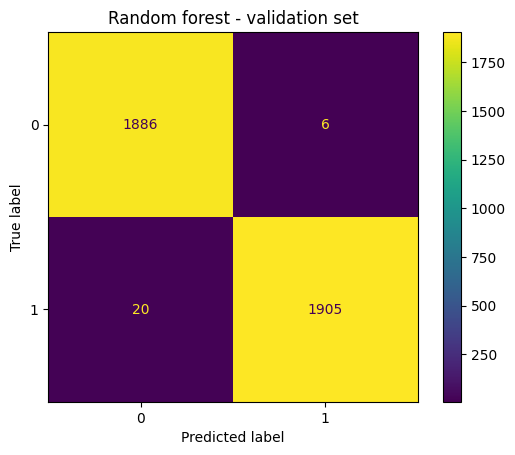

In [90]:
# Create a confusion matrix to visualize the results of the classification model

# Compute values for confusion matrix
log_cm = confusion_matrix(y_val, y_pred)

# Create display of confusion matrix using ConfusionMatrixDisplay()
log_disp = ConfusionMatrixDisplay(log_cm, display_labels= None)

# Plot confusion matrix
log_disp.plot()
# Display plot
plt.title('Random forest - validation set');
plt.show()

Creating a classification report that includes precision, recall, f1-score, and accuracy metrics to evaluate the performance of the model.
<br> </br>


In [91]:
# Create a classification report
# Create classification report for random forest model
trarget_labels = ['opinion', 'claim']
print(classification_report(y_val, y_pred, target_names= trarget_labels))

              precision    recall  f1-score   support

     opinion       0.99      1.00      0.99      1892
       claim       1.00      0.99      0.99      1925

    accuracy                           0.99      3817
   macro avg       0.99      0.99      0.99      3817
weighted avg       0.99      0.99      0.99      3817



The classification report indicates that the random forest model achieved near-identical scores across the board. The confusion matrix shows 26 misclassifications, including 4 false positives and 2 false negatives.

#### **XGBoost**

Now, an evaluation of the XGBoost model on the validation set.

In [92]:
# Use the best estimator to predict on the validation data

y_pred = xgb_cv.best_estimator_.predict(X_val)

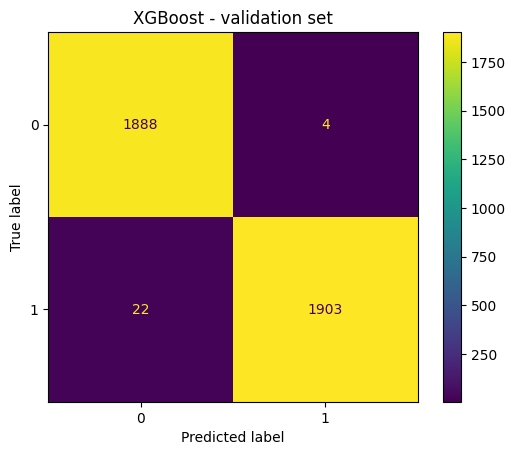

In [93]:
# Compute values for confusion matrix
log_cm = confusion_matrix(y_val, y_pred)

# Create display of confusion matrix using ConfusionMatrixDisplay()
log_disp = ConfusionMatrixDisplay(confusion_matrix= log_cm, display_labels= None)
# Plot confusion matrix

log_disp.plot()

# Display plot
plt.title('XGBoost - validation set');
plt.show()

In [94]:
# Create a classification report
trarget_labels = ['opinion', 'claim']
print(classification_report(y_val, y_pred, target_names= trarget_labels))


              precision    recall  f1-score   support

     opinion       0.99      1.00      0.99      1892
       claim       1.00      0.99      0.99      1925

    accuracy                           0.99      3817
   macro avg       0.99      0.99      0.99      3817
weighted avg       0.99      0.99      0.99      3817



The classification report suggests that the random forest model achieved perfect scores, but this is misleading. The confusion matrix shows 26 misclassifications, including 4 false positives and 22 false negatives.

### **Selection of the Champion Model for Predicting Test Data**

Both the random forest and XGBoost models performed almost perfectly, with very similar scores. However, the random forest model slightly outperformed XGBoost with a recall score of 0.999, compared to XGBoost's 0.998. Therefore, the random forest model was selected as the champion for prediction.

In [95]:
y_pred = rf_cv.best_estimator_.predict(X_test)


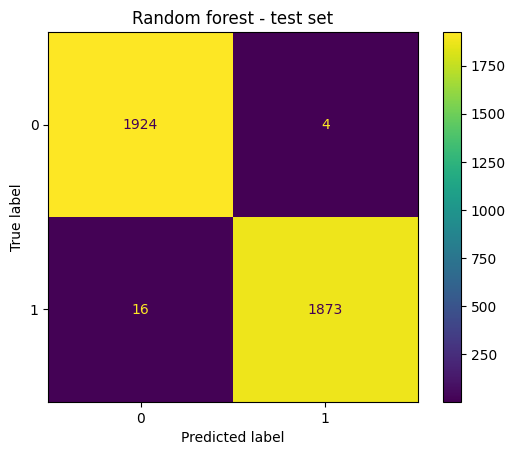

In [96]:
# Compute values for confusion matrix
log_cm = confusion_matrix(y_test, y_pred)

# Create display of confusion matrix
log_disp = ConfusionMatrixDisplay(confusion_matrix=log_cm, display_labels=None)

# Plot confusion matrix
log_disp.plot()

# Display plot
plt.title('Random forest - test set');
plt.show()


#### **Feature importances of champion model**


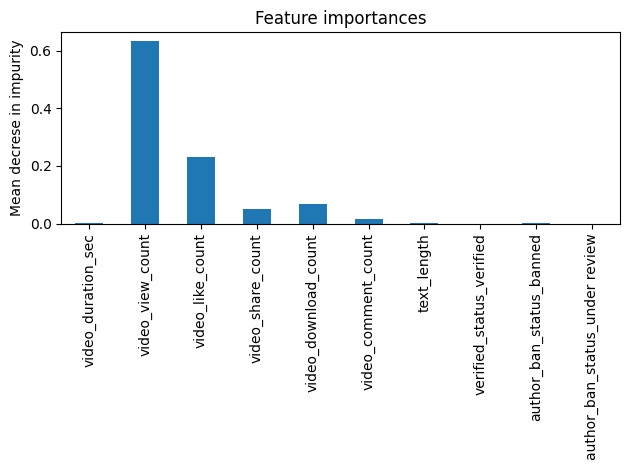

In [97]:
importances = rf_cv.best_estimator_.feature_importances_
rf_importances = pd.Series(importances, index = X_test.columns)

fig, ax = plt.subplots()
rf_importances.plot.bar(ax = ax)
ax.set_title('Feature importances')
ax.set_ylabel('Mean decrese in impurity')

fig.tight_layout()

The most predictive features were all associated with the video's engagement levels. This aligns with expectations, as previous exploratory data analysis (EDA) indicated a similar pattern.

### **Task 8. Conclusion**


The XGBoost model is recommended due to its strong performance on both validation and test holdout data. It achieved excellent recall scores, and both precision and F1 scores remained consistently high, demonstrating its ability to effectively differentiate between claims and opinions.

The model relied heavily on user engagement metrics, such as views, likes, shares, and downloads, to classify videos.

Given the model's near-perfect performance, there is currently no immediate need for additional feature engineering. However, incorporating the number of times a video was reported could provide valuable insights. Tracking the total number of user reports for all videos posted by a specific author could further enhance the model's performance.